In [1]:
import snapatac2 as snap
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import os
import sys
#sys.path.append('..')
#import Py_mTCall_tools.variant_calling
import importlib
#from Py_mTCall_tools import process_and_integrate_variants  # Use the package name from setup.py
import kaleido
import plotly.io as pio
import matplotlib.pyplot as plt


/home/elliot/miniconda3/envs/elliotenv/lib/python3.11/site-packages/kaleido/_sync_server.py:11: UserWarning: 


This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

  from .kaleido import Kaleido


In [2]:
data = snap.pp.import_fragments(
    "/mnt/claw-raid/elliot//Mike_keogh_mtscATAC/241121-cortex_results_masked/fragments.tsv.gz",
    chrom_sizes=snap.genome.hg38,  #
    sorted_by_barcode=False,
)
data          

AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences'
    obsm: 'fragment_paired'

In [3]:
## Bit of extra information:
'''
1. Nucleosome-Free Region (NFR): The majority of fragments are short, typically around 80-300 base pairs (bp) in length. 
These short fragments represent regions of open chromatin where DNA is relatively accessible and not bound to nucleosomes. 
These regions are often referred to as nucleosome-free regions (NFRs) and correspond to regions of active transcriptional 
regulation.

2. Mono-Nucleosome Peaks: There is often a peak in the fragment size distribution at around 147-200 bp, 
which corresponds to the size of a single nucleosome wrapped DNA. These fragments result from the 
cutting of DNA by the transposase enzyme when it encounters a nucleosome, 
causing the DNA to be protected and resulting in fragments of the same size.

3. Di-Nucleosome Peaks: In addition to the mono-nucleosome peak, you may also observe 
a smaller peak at approximately 300-400 bp, corresponding to di-nucleosome fragments. 
These fragments occur when transposase cuts the DNA between two neighboring nucleosomes.

4. Large Fragments: Some larger fragments, greater than 500 bp in size, may be observed. 
These fragments can result from various sources, such as the presence of 
longer stretches of open chromatin or technical artifacts.
'''

#Idk why this isn't wokring something to do with chrome wtf

snap.pl.frag_size_distr(data, interactive=True)

2025-11-14 16:15:55 - INFO - Computing fragment size distribution...


In [4]:
## Same plot with axis to log scale
fig = snap.pl.frag_size_distr(data, show=False)
fig.update_yaxes(type="log")
fig.show()

In [5]:
## TSS enrichment implies there is an increased accessibility or fragmentation of chromatin around the TSS
## Often indicative of promoter regions
snap.metrics.tsse(data, snap.genome.hg38)

In [6]:
## To identify usable/high-quality cells, we can plot TSSe scores against number of unique fragments for each cell.
snap.pl.tsse(data, interactive=True)
data
##The cells in the upper right represent valid or high-quality cells, whereas those in the lower left represent low-quality 
# cells or empty droplets. Based on this plot, 
#we decided to set a minimum TSS enrichment of 10 and a minimum number of fragments of 5,000 to filter the cells.

/home/elliot/miniconda3/envs/elliotenv/lib/python3.11/site-packages/snapatac2/plotting/__init__.py:97: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/home/elliot/miniconda3/envs/elliotenv/lib/python3.11/site-packages/snapatac2/plotting/__init__.py:98: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



AnnData object with n_obs × n_vars = 65340 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [7]:
## OprionL - Filtering cells here results in fewer mitochondrial variants deteced
snap.pp.filter_cells(data, min_counts=1000, min_tsse=10, max_counts=100000)
data

AnnData object with n_obs × n_vars = 1228 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile'
    obsm: 'fragment_paired'

In [8]:
## Cell by bin matrix containng insertion counts across 500bp bins across the genome
snap.pp.add_tile_matrix(data)

In [9]:
## Feature selection, which will be stored in data.var['selected'] this is particularly relevant for scrublet and spectral
## Selects most accessible features 
## n_features determines number of features, experiment with n_features to find the optimal number for your dataset
snap.pp.select_features(data, n_features=250000)

2025-11-14 16:16:18 - INFO - Selected 250000 features.


In [10]:

## Scrublet is used to remove potential dublets. It will assign probabilities to each cell, and then we can filter
snap.pp.scrublet(data, features=data.var['selected'].values)
#snap.pp.scrublet(data)
snap.pp.filter_doublets(data)
data

2025-11-14 16:16:18 - INFO - Simulating doublets...
2025-11-14 16:16:18 - INFO - Spectral embedding ...
2025-11-14 16:16:42 - INFO - Calculating doublet scores...
2025-11-14 16:16:43 - INFO - Detected doublet rate = 1.303%


AnnData object with n_obs × n_vars = 1212 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate'
    obsm: 'fragment_paired'

In [11]:
## Spectral embedding is used for dimensionality reduction
## Stored in data.obsm['X_spectral']
snap.tl.spectral(data)
snap.tl.umap(data)

/home/elliot/miniconda3/envs/elliotenv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [12]:
## Perform graph based clustering, build k-nearest neighbour graph then use leiden algorithm to identify clusters
snap.pp.knn(data)
snap.tl.leiden(data, resolution=0.7)  # Adjust resolution for more or fewer clusters

In [13]:
snap.pl.umap(data, color='leiden', interactive=True, height=500)

In [17]:
#ELLIOT - lucas' Clustering done annotation begins 
## Annotate the clusters and assign them to known cell types
## Compute gene activities for each cell using pp.make_gene_matrix

gene_matrix = snap.pp.make_gene_matrix(data, snap.genome.hg38)
print(f"Number of cells: {gene_matrix.n_obs}")
gene_matrix
data



Number of cells: 1212


AnnData object with n_obs × n_vars = 1212 × 6062095
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden'
    var: 'count', 'selected'
    uns: 'reference_sequences', 'frag_size_distr', 'library_tsse', 'frac_overlap_TSS', 'TSS_profile', 'scrublet_sim_doublet_score', 'doublet_rate', 'spectral_eigenvalue'
    obsm: 'fragment_paired', 'X_spectral', 'X_umap'
    obsp: 'distances'

In [ ]:
### The cell by gene activity matrix is sparse
## The MAGIC algorithm performs imputation and data smoothing
## Then scanpy does subsequent steps 
## First perform gene filtering, normalisation and transformation and then call MAGIC
sc.pp.filter_genes(gene_matrix, min_cells= 5)
sc.pp.normalize_total(gene_matrix)
sc.pp.log1p(gene_matrix)
# Skip MAGIC imputation - the analysis will work fine without it
# sc.external.pp.magic(gene_matrix, solver="approximate")

# Copy over UMAP embedding
gene_matrix.obsm["X_umap"] = data.obsm["X_umap"]

In [18]:
#ELLIOT - Lucas' annotation method 
#import RNA reference data
reference = snap.read('/mnt/claw-raid/elliot/human_cortex_ref.h5ad', backed=None)
reference

AnnData object with n_obs × n_vars = 6235 × 50281
    obs: 'class', 'cluster', 'subclass', 'donor_sex', 'region', 'cortical_layer', 'external_donor_name'
    var: 'features'

In [7]:
# Save your gene matrix
data.write('gene_activity.h5ad')


In [8]:
#New environment

import scanpy as sc
import scvi
import anndata as ad
import pandas as pd
import skmisc
import numpy as np  

In [9]:
#NEW ENVIRONEMENT
#Load data 
data = sc.read_h5ad('gene_activity.h5ad')
reference = sc.read_h5ad('/mnt/claw-raid/elliot/human_cortex_ref.h5ad')

In [6]:
print(reference.obs['subclass'].unique())


['LAMP5' 'VIP' 'IT' 'PVALB' 'L4 IT' 'Oligodendrocyte' 'L6 CT'
 'L5/6 IT Car3' 'L5/6 NP' 'Astrocyte' 'L6b' 'Microglia' 'NA' 'Endothelial'
 'OPC' 'SST' 'L5 ET' 'Pericyte' 'PAX6' 'VLMC']


In [ ]:
print(reference.obs['cluster'].head(100))
#print(data.obs)

F2S4_180207_011_A01    LAMP5
F2S4_180207_011_B01      VIP
F2S4_180207_011_C01      VIP
F2S4_180207_011_E01       IT
F2S4_180207_011_F01      VIP
                       ...  
F2S4_180207_005_D01      VIP
F2S4_180207_005_F01    LAMP5
F2S4_180207_005_G01    LAMP5
F2S4_180207_005_H01       IT
F2S4_180207_006_B01    LAMP5
Name: subclass, Length: 100, dtype: object


In [12]:
#ELLIOT - Merge reference data and query data


data = ad.concat(
    [reference, data],
    join='outer',  # Changed to 'outer' to keep all columns
    label='batch',
    keys=["reference", "query"],
    index_unique='_',
)
data

/tmp/ipykernel_800185/3389871881.py:4: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  data = ad.concat(


AnnData object with n_obs × n_vars = 7447 × 72082
    obs: 'class', 'cluster', 'subclass', 'donor_sex', 'region', 'cortical_layer', 'external_donor_name', 'n_fragment', 'frac_dup', 'frac_mito', 'tsse', 'doublet_probability', 'doublet_score', 'leiden', 'batch'

In [13]:
# scanpy finds highly variable genes (batch correction)
#if you ask callum he will say this is shit because this is porabbly just to make it faster
sc.pp.filter_genes(data, min_cells=5)
sc.pp.highly_variable_genes(
    data,
    n_top_genes = 5000,
    flavor="seurat_v3",
    batch_key="batch",
    subset=True
)

In [14]:
#set up machine learning 
scvi.model.SCVI.setup_anndata(data, batch_key="batch")
vae = scvi.model.SCVI(
    data,
    n_layers=2,
    n_latent=30,
    gene_likelihood="nb",
    dispersion="gene-batch",
)

In [15]:
#pretraining model?
vae.train(max_epochs=1000, early_stopping=True)


/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider in

Epoch 330/1000:  33%|███▎      | 330/1000 [06:12<12:35,  1.13s/it, v_num=1, train_loss=4.43e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 4783.223. Signaling Trainer to stop.


<Axes: xlabel='epoch'>

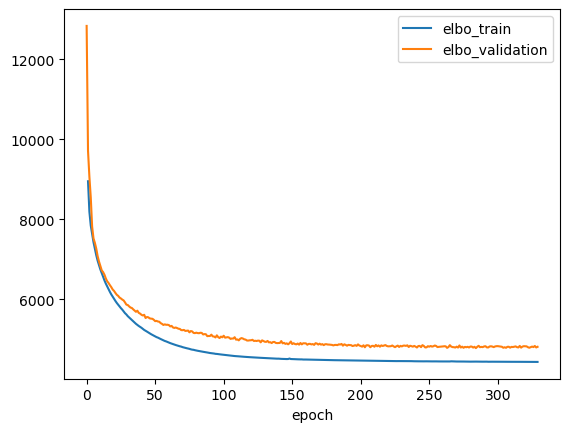

In [16]:
#plot training model to make sure it has converged 
ax = vae.history['elbo_train'][1:].plot()
vae.history['elbo_validation'].plot(ax=ax)


In [17]:
#setting up training model, check the 'class' or quivalent column is presetn in the refernce an merged object 
data.obs["celltype_scanvi"] = 'Unknown'
ref_idx = data.obs['batch'] == "reference"
data.obs.loc[ref_idx, "celltype_scanvi"] = data.obs.loc[ref_idx, 'subclass'].astype(str)


In [9]:
#load saved vae model
vae = scvi.model.SCVI.load("/mnt/claw-raid/elliot/vae_model/", adata=data)


INFO     File /mnt/claw-raid/elliot/vae_model/model.pt already downloaded                                          


/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/scvi/model/base/_base_model.py:849: UserWarning: `var_names` for the loaded `model` does not match those used to train the model. For valid results, the former should match the latter.
  _validate_var_names(adata, var_names)


In [18]:
#who knows what this does maybe callum 
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=data,
    labels_key="celltype_scanvi",
    unlabeled_category="Unknown",
)

/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/scvi/data/fields/_dataframe_field.py:187: UserWarning: Category 20 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/scvi/data/fields/_scanvi.py:56: UserWarning: Category 18 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(


In [19]:
lvae.train(max_epochs=400, n_samples_per_label=100, early_stopping=True)

INFO     Training for 400 epochs.                                                                                  


/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider in

Epoch 46/400:  12%|█▏        | 46/400 [02:05<16:03,  2.72s/it, v_num=1, train_loss=4.41e+3]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 4482.577. Signaling Trainer to stop.


In [20]:
#load and plot model if you've saved it 
lvae = torch.load('/mnt/claw-raid/elliot/lvae_model/model.pt', weights_only=False)
lvae['attr_dict']['history_']['elbo_train'][1:].plot()


NameError: name 'torch' is not defined

<Axes: xlabel='epoch'>

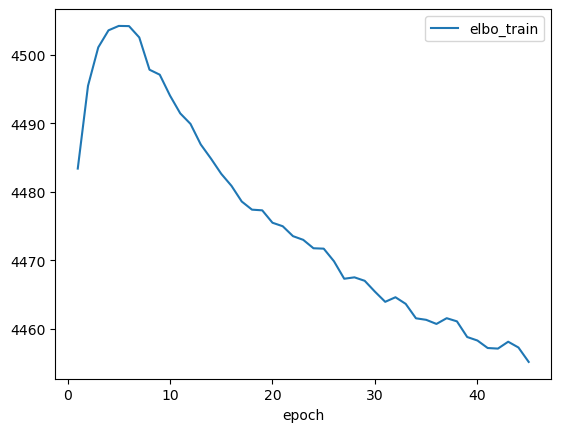

In [21]:
#plotting history as normal (if not saved)
lvae.history['elbo_train'][1:].plot()


In [ ]:

#IF SAVED how to use the models 

# Setup the data labels as before
data.obs["celltype_scanvi"] = 'Unknown'
ref_idx = data.obs['batch'] == "reference"
data.obs.loc[ref_idx, "celltype_scanvi"] = data.obs.loc[ref_idx, 'class'].astype(str)

# Load the base scVI model
vae = scvi.model.SCVI.load('/mnt/claw-raid/elliot/vae_model/', adata=data)

# Load the SCANVI model
lvae = scvi.model.SCANVI.load('/mnt/claw-raid/elliot/lvae_model/', adata=data)

# Now you can use the model
data.obs["C_scANVI"] = lvae.predict()
data.obsm["X_scANVI"] = lvae.get_latent_representation()



INFO     File /mnt/claw-raid/elliot/vae_model/model.pt already downloaded                                          


INFO     File /mnt/claw-raid/elliot/lvae_model/model.pt already downloaded                                         


/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...
/home/elliot/miniconda3/envs/scvi_env/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/elliot/miniconda3/envs/scvi_env/lib/python3.13 ...


In [22]:
# Now you can use the model
data.obs["C_scANVI"] = lvae.predict()
data.obsm["X_scANVI"] = lvae.get_latent_representation()

In [23]:
#generating uMAP
sc.pp.neighbors(data, use_rep="X_scANVI")
sc.tl.umap(data)

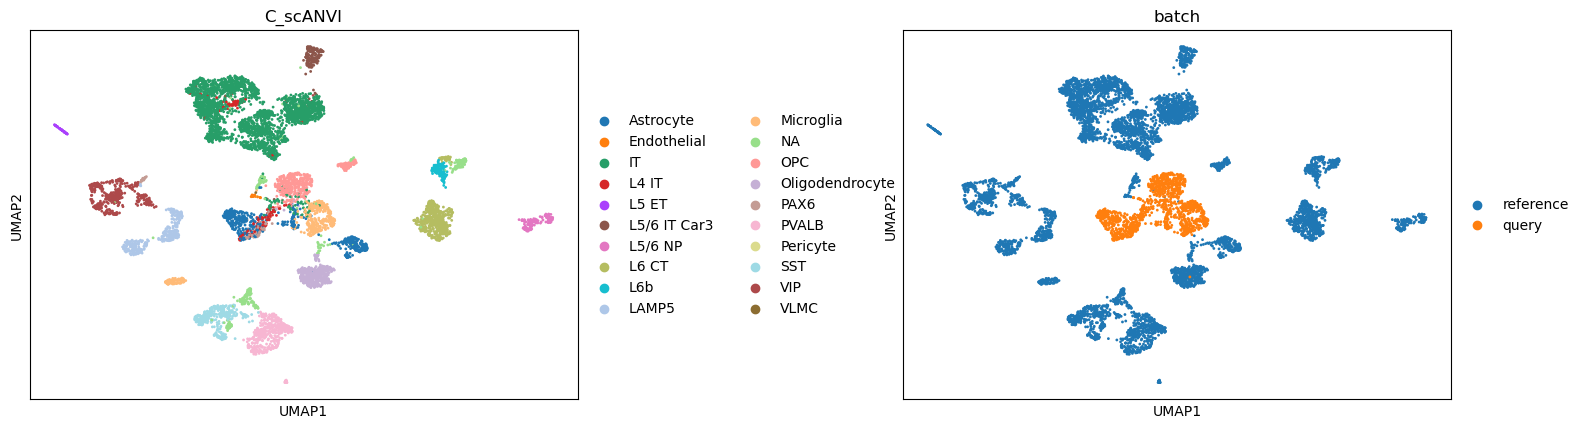

In [24]:
#Plotting uMAP querey and reference
sc.pl.umap(data, color=['C_scANVI', "batch"], wspace=0.45)


In [1]:
#back to snapatac2 environment 
#save atac data 
data.write('/mnt/claw-raid/elliot/atac_processed.h5ad')


NameError: name 'data' is not defined

In [ ]:
atac.obs['cell_type'] = data.obs.loc[suffixed_names, 'C_scANVI'].to_numpy()


NameError: name 'data' is not defined

2025-11-06 12:56:29 - INFO - 🔬 Input data has 7628 cells and 58534 genes
2025-11-06 12:56:29 - INFO - 🔗 Matching reference genes in the model
2025-11-06 12:56:32 - INFO - 🧬 3327 features used for prediction
2025-11-06 12:56:32 - INFO - ⚖️ Scaling input data
2025-11-06 12:56:35 - INFO - 🖋️ Predicting labels
2025-11-06 12:56:35 - INFO - ✅ Prediction done!
2025-11-06 12:56:35 - INFO - 👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
2025-11-06 12:56:35 - INFO - ⛓️ Over-clustering input data with resolution set to 10
2025-11-06 12:56:41 - INFO - 🗳️ Majority voting the predictions
2025-11-06 12:56:41 - INFO - ✅ Majority voting done!


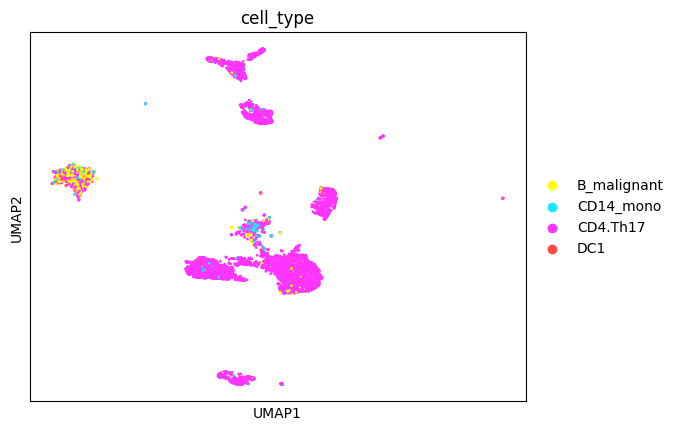


Cell type distribution:
cell_type
CD4.Th17       6317
B_malignant     870
CD14_mono       357
DC1              84
Name: count, dtype: int64

Prediction confidence summary:
       predicted_labels over_clustering majority_voting
count              7628            7628            7628
unique               38             146               4
top            CD4.Th17               0        CD4.Th17
freq               4078             201            6317


In [ ]:
#ELLIOT - Cell typist annotation
import celltypist
import scanpy as sc

# Prepare data properly for CellTypist
# Work with a copy to avoid modifying your original data
gene_matrix_ct = gene_matrix.copy()

# Store raw counts if not already stored
if gene_matrix_ct.raw is None:
    gene_matrix_ct.raw = gene_matrix_ct.copy()

# Normalize to 10,000 counts per cell, then log1p transform
sc.pp.normalize_total(gene_matrix_ct, target_sum=1e4)
sc.pp.log1p(gene_matrix_ct)

# Use CellTypist with properly normalized data
predictions = celltypist.annotate(
    gene_matrix_ct, 
    model='Healthy_COVID19_PBMC.pkl', 
    majority_voting=True
)

# Add the annotations back to original objects
gene_matrix.obs['cell_type'] = predictions.predicted_labels['majority_voting']
data.obs['cell_type'] = predictions.predicted_labels['majority_voting']

# Visualize (use original gene_matrix which should have UMAP coordinates)
sc.pl.umap(gene_matrix, color='cell_type')

# Print results
print("\nCell type distribution:")
print(gene_matrix.obs['cell_type'].value_counts())

# Optional: Show prediction confidence
print("\nPrediction confidence summary:")
print(predictions.predicted_labels.describe())

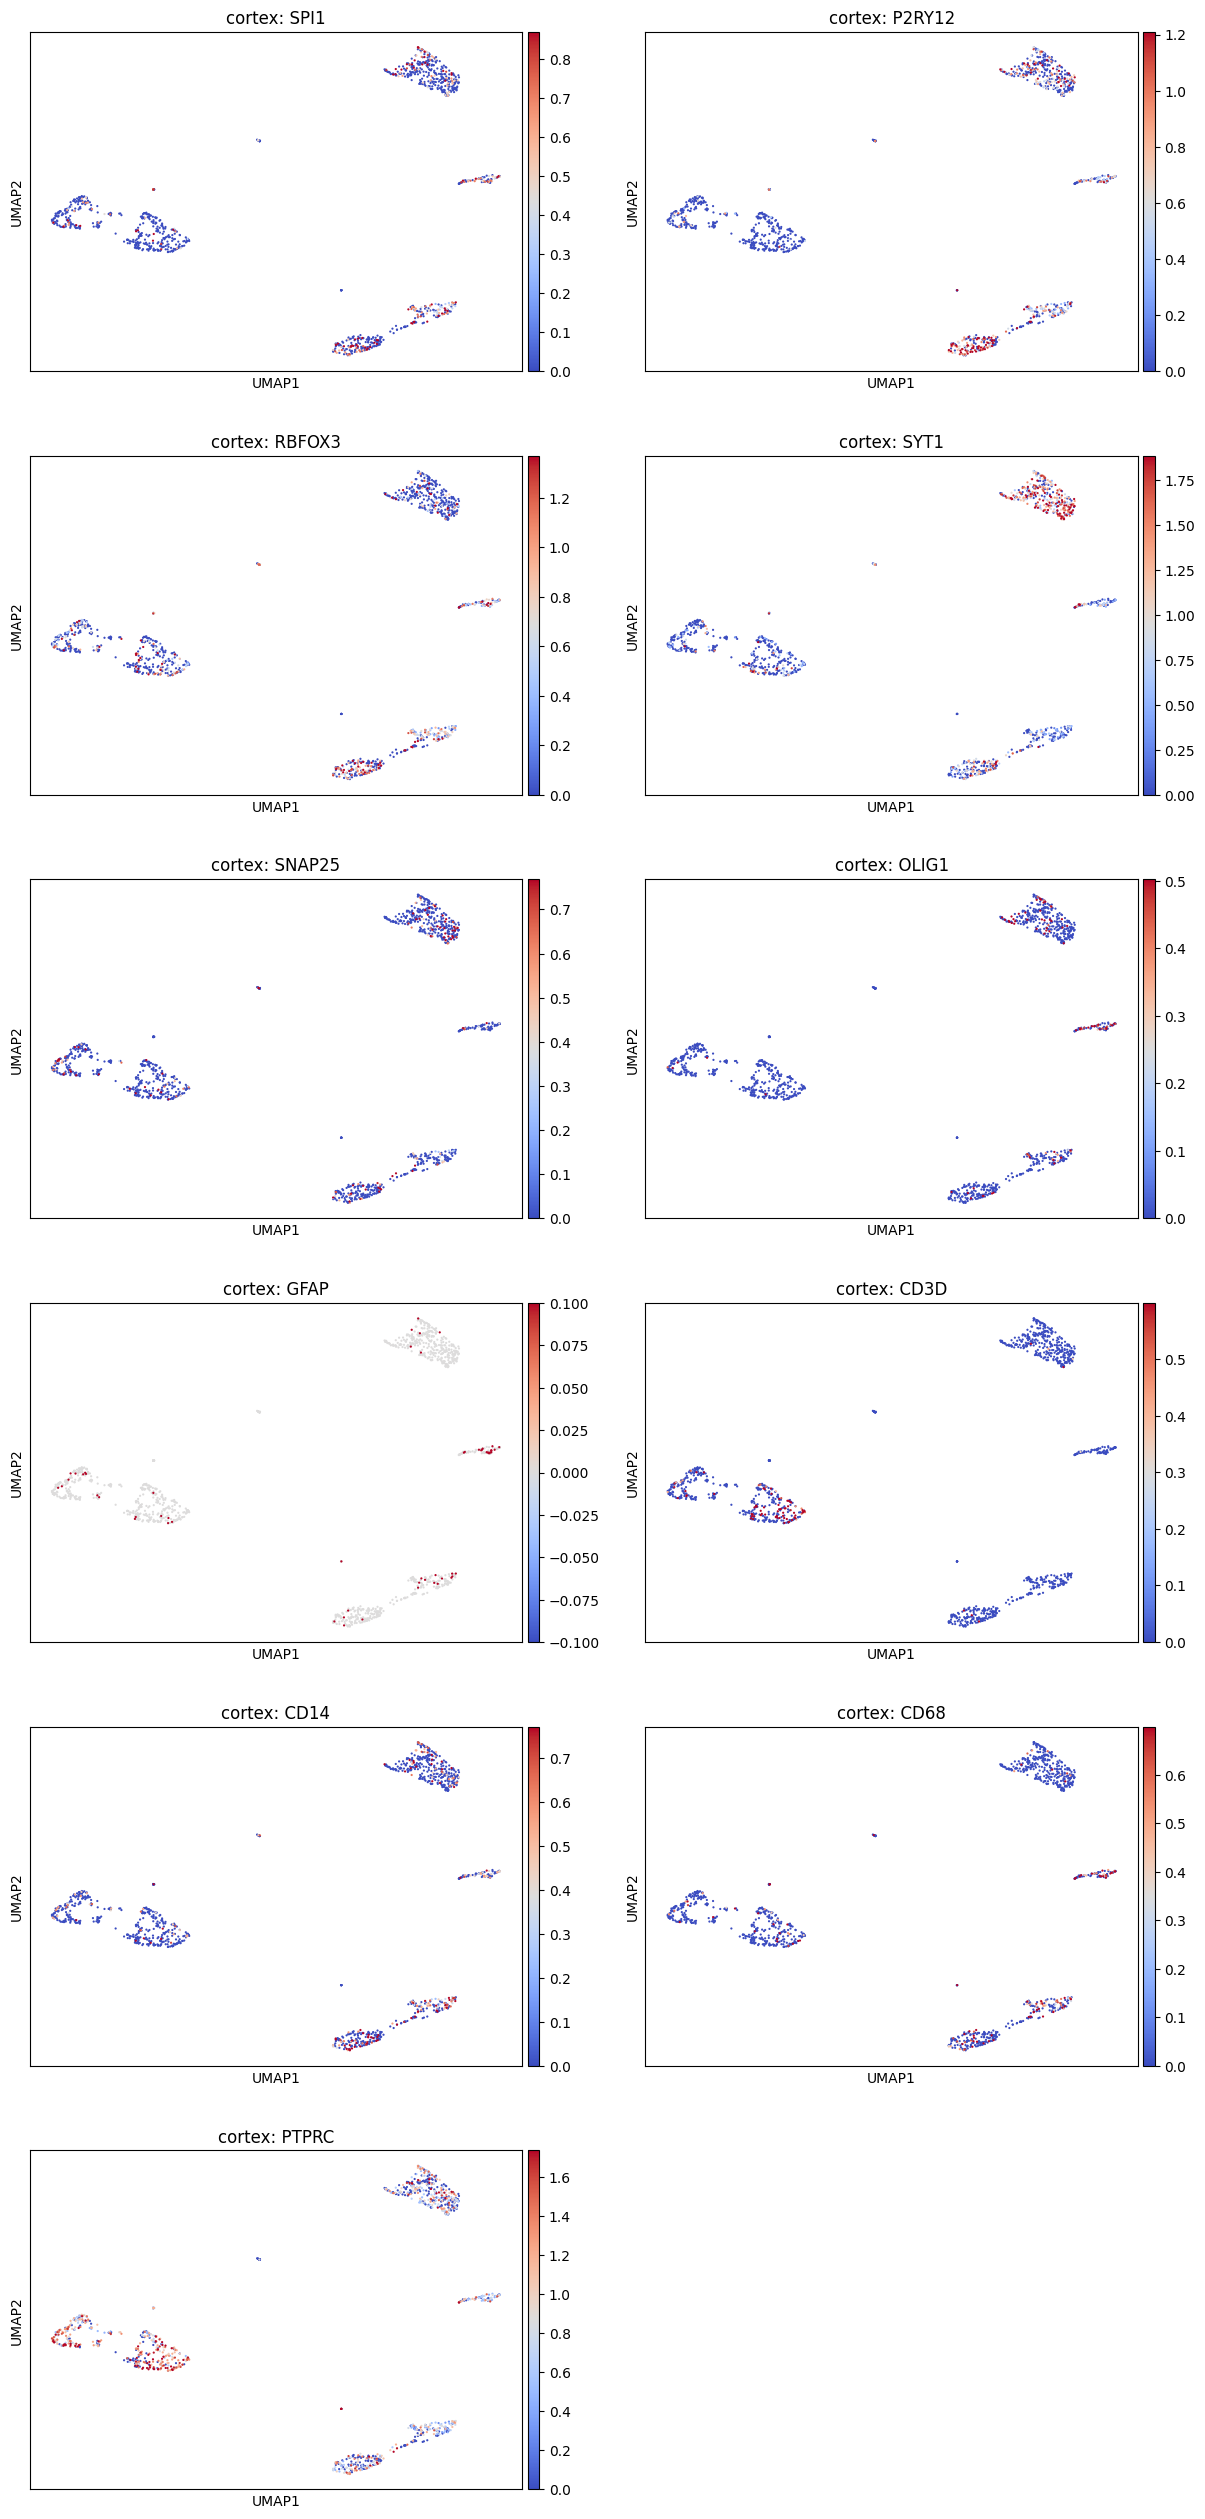

In [ ]:
import matplotlib.pyplot as plt

# Define marker genes for each cell type
celltype_markers = {
    #'PBMCs': ["CD4","CD8A","CD3D","NCAM1","FCGR3A","CD14","CD1C","CLEC9A","IL3RA","GZMB","C5AR1","CD34","CD19","MS4A1"], ## PTPRC is CD45, sample should be 70/30 CD4+/CD4-
    'cortex': ["SPI1","P2RY12","RBFOX3","SYT1","SNAP25","OLIG1","GFAP","CD3D","CD14","CD68","PTPRC"],
  
}

# Plot UMAPs for each cell type's marker genes
for celltype, genes in celltype_markers.items():
    sc.pl.umap(
        gene_matrix, 
        color=genes, 
        ncols=2, 
        cmap='coolwarm',
        vmax='p95',
        size=10,
        title=[f"{celltype}: {gene}" for gene in genes],
        show=True
    )
plt.show()


In [ ]:
#Elliot - mkaing a DEGs list actually, gene_matrix is an object NOT an acutal matrix 

# Get the number of top genes (should be 20 based on your plot)
n_genes = len(gene_matrix.uns['rank_genes_groups']['names'])

# Create a dictionary with DEG lists for each cluster
deg_lists = {}
for i in range(n_genes):
    for j, cluster in enumerate(gene_matrix.uns['rank_genes_groups']['names'].dtype.names):
        if cluster not in deg_lists:
            deg_lists[cluster] = []
        deg_lists[cluster].append(gene_matrix.uns['rank_genes_groups']['names'][i][j])

# Now deg_lists contains clean lists of top DEGs for each cluster
for cluster, genes in deg_lists.items():
    print(f"Cluster {cluster}: {genes[:20]}...")  # Show first 5 genes

Cluster 0: ['LRP1B', 'GRID2', 'ENSG00000231918', 'CNTN5', 'CNTNAP2', 'DPP10', 'ENSG00000251574', 'EYS', 'ROBO2', 'ERBB4', 'DMD', 'NAALADL2', 'CSMD3', 'ENSG00000254394', 'CDH18', 'RBMS3', 'ROBO1', 'ENSG00000248752', 'SPAG16', 'CADM2']...
Cluster 1: ['PELATON', 'CDH23', 'ENSG00000285565', 'RAD51B', 'PSAP', 'DAPK1', 'SLC24A4', 'PGS1', 'ENSG00000234261', 'PFKFB3', 'ZMIZ1', 'ENSG00000273112', 'HSPD1', 'MGAT1', 'BAG3', 'MBP', 'HSPH1', 'ENSG00000285016', 'DNAJB6', 'XYLT1']...
Cluster 2: ['ENSG00000234261', 'LINC00877', 'SCIRT', 'ENSG00000258137', 'HK2', 'JARID2', 'ZMIZ1', 'ENSG00000258086', 'CUX1', 'PRKAG2', 'RBM47', 'RIN2', 'SLCO3A1', 'GAS7', 'RFX2', 'NCOR2', 'TIMP2', 'ENSG00000289728', 'DMXL2', 'FNDC3B']...
Cluster 3: ['HK2', 'CUX1', 'FNDC3B', 'RUNX1', 'PRKAG2', 'MAML3', 'JARID2', 'ASAP1', 'ENSG00000289728', 'DOCK5', 'ENSG00000259345', 'SLCO3A1', 'RPTOR', 'SLC24A4', 'ENSG00000286022', 'IGF2BP2', 'DOCK2', 'PPARG', 'LUCAT1', 'NIBAN2']...
Cluster 4: ['BCL11B', 'RORA', 'RORA-AS1', 'SCML4', 'ITK

... storing 'leiden' as categorical


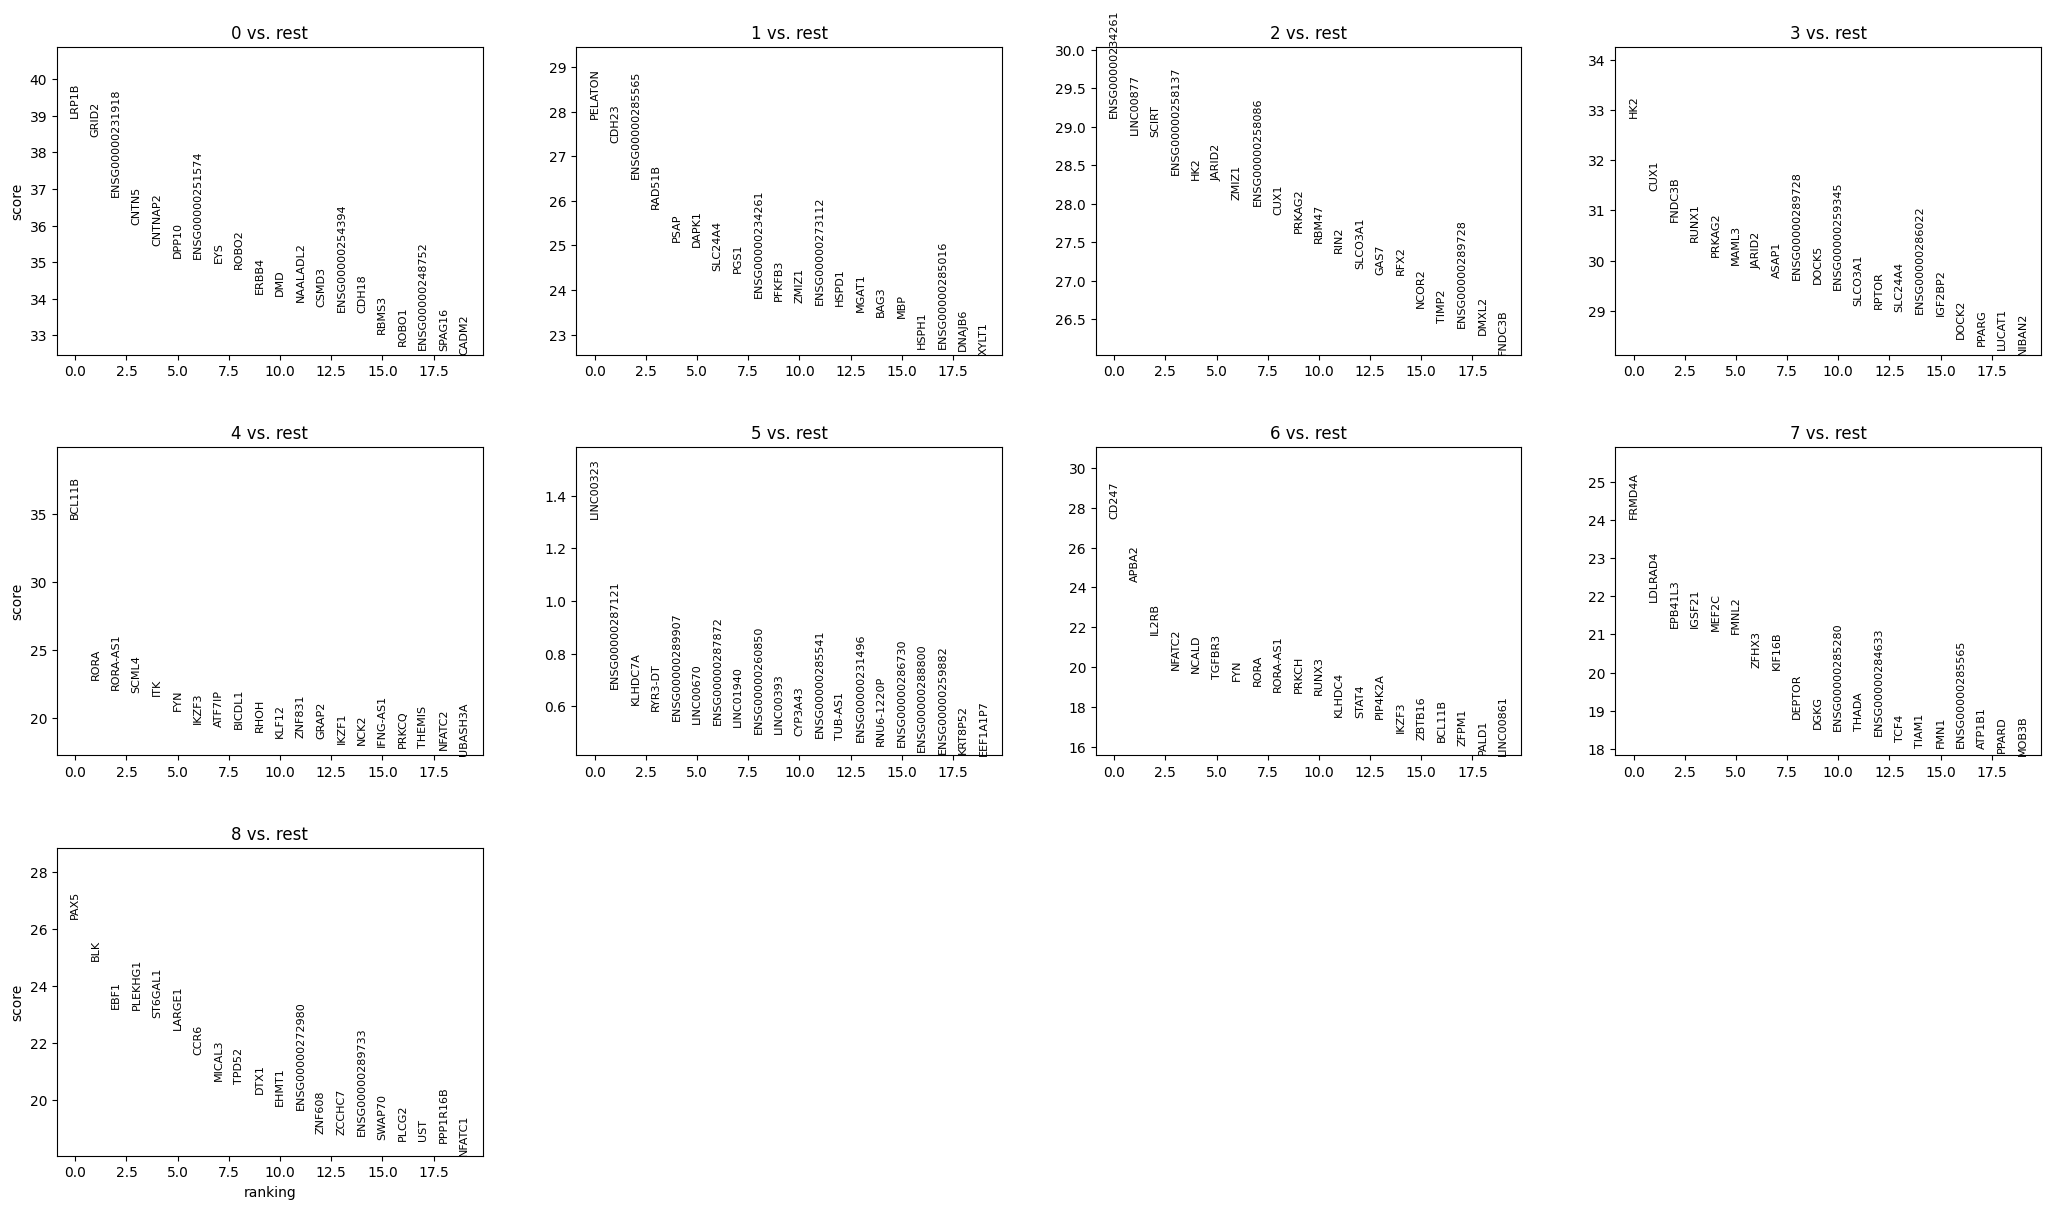

In [ ]:
# Run differential expression analysis between clusters (e.g., 'leiden' clusters)
sc.tl.rank_genes_groups(gene_matrix, groupby='leiden', method='wilcoxon')

# Show the top marker genes for each cluster
sc.pl.rank_genes_groups(gene_matrix, n_genes=20, sharey=False)



In [ ]:
##Not clear what the clusters are so I am going to do vague annotations
##Annotatig 
cluster_to_celltype = {
    "6": "CD4 T cell",
    "0": "Macrophage",
    "3": "CD8 T cell",
    "1": "NK cell",
    "2": "Monocytes",
    "4": "Unsure",
    "5": "Unsure",
    "7": "B cell"
   
    # Add more as needed
}

... storing 'celltype' as categorical


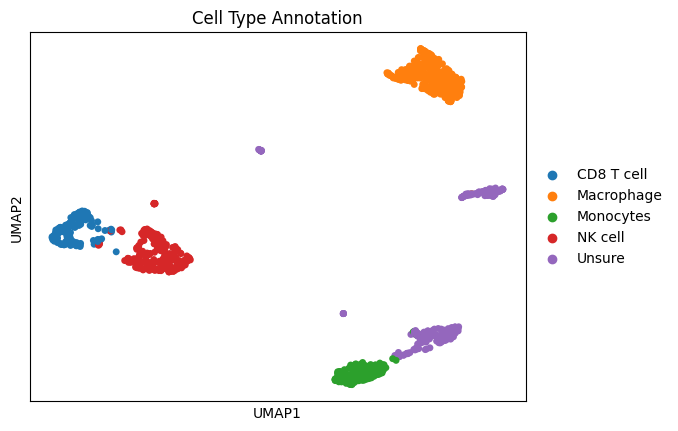

In [ ]:
gene_matrix.obs['celltype'] = gene_matrix.obs['leiden'].map(cluster_to_celltype)
sc.pl.umap(gene_matrix, color=['celltype'], title="Cell Type Annotation")

In [ ]:
# !!!!!!!!!!!!!!!!!! !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!OK SO NOW THE MT VARIANT CALLING BEGINS STOP HERE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
import sys
sys.path.insert(0, '/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Py-mTCall')
# Fix: Use uppercase 'Py_mTCall_tools' instead of lowercase 'py_mTCall_tools'
import Py_mTCall_tools.variant_calling_fast as vc
mgatk = vc.process_variants_fast("/Users/lucascortes/Documents/Pickett/Mike_Keogh/Data/241121-PBMC_results_masked/final", gene_matrix)



ModuleNotFoundError: No module named 'Py_mTCall_tools'

In [ ]:
variants = mgatk.uns['variant_names']
variants_formatted = []
for i in range(len(variants)):
    parts = variants[i].split('-')
    variants_formatted.append(parts[1] + parts[2] + '>' + parts[0])
variants_swapped_df = pd.DataFrame(variants_formatted, columns=['variant'])
variants_swapped_df.to_csv("/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/Mike_Keogh/analysis/PBMC_Surgical/PBMC_Surgical_variants_swapped.csv", index=False)
signac_variants = pd.read_csv("/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/Mike_Keogh/analysis/PBMC_Surgical/PBMC_surgical_variants_mgatk.csv", header=0)
signac_variants = signac_variants.iloc[:, 1]
signac_variants_list = signac_variants.tolist()

# Compare the two lists
matching_variants = set(variants_formatted).intersection(set(signac_variants_list))
print(f"Matching variants: {matching_variants}")
print(len(matching_variants))

Matching variants: {'3226G>A', '5578T>C', '618T>C', '4939T>C', '916C>T', '7176T>C', '788T>C', '15726T>C', '13064T>C', '5634A>T', '8986A>G', '4728A>G', '9592T>C', '929A>G', '1100C>A', '11184G>A', '13070C>T', '8854G>A', '2813T>C', '7797T>C', '297A>G', '830T>G', '9136A>G', '1079G>A', '9589A>G', '7411A>G', '8618T>C', '3916G>A', '12223A>G', '7842T>C', '5006A>T', '1888G>A', '10161A>G', '368A>G', '15027T>C', '525C>T', '15183T>C', '14904T>C', '3127G>A', '8556T>C', '11964T>C', '7296G>A', '12170G>A', '15687G>A', '3656T>C', '4449G>A', '11800A>G', '1180T>C', '6176T>C', '2174G>A', '466T>C', '2861A>T', '6799T>C', '1178G>A', '11561G>A', '12443T>C', '12681T>C', '5608C>G', '13345G>A', '11316T>C', '8093T>C', '5951A>G', '10692C>T', '7025A>G', '5698G>A', '3919T>C', '3022G>A', '1172C>T', '13208G>A', '11140C>T', '6356C>T', '7100A>G', '3682A>C', '14123T>C', '16169C>T', '6371C>T', '7673A>G', '3118T>C', '11948G>A', '1380G>A', '8900T>C', '4290T>C', '12808T>C', '14152A>G', '10654C>A', '2932G>A', '15235A>C', '131

Plotting first 5 confident variants out of 4710 total confident variants
Processing variant 1: Index 0, Name: A-10172-G


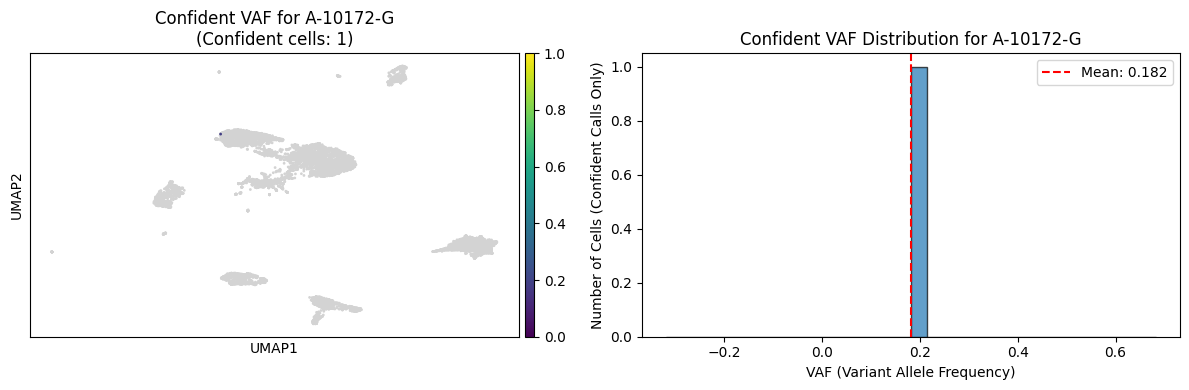

Variant A-10172-G (Index 0):
  Confident cells detected: 1
  Mean coverage: 24.7
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.182
  Confident VAF range: 0.182 - 0.182
---
Processing variant 2: Index 1, Name: A-10726-G


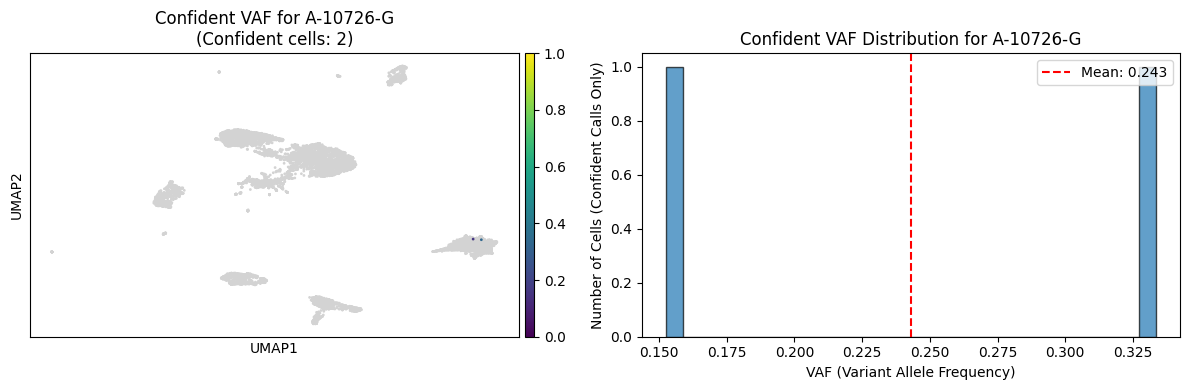

Variant A-10726-G (Index 1):
  Confident cells detected: 2
  Mean coverage: 20.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 2
  Mean confident VAF: 0.243
  Confident VAF range: 0.153 - 0.333
---
Processing variant 3: Index 2, Name: A-11163-G


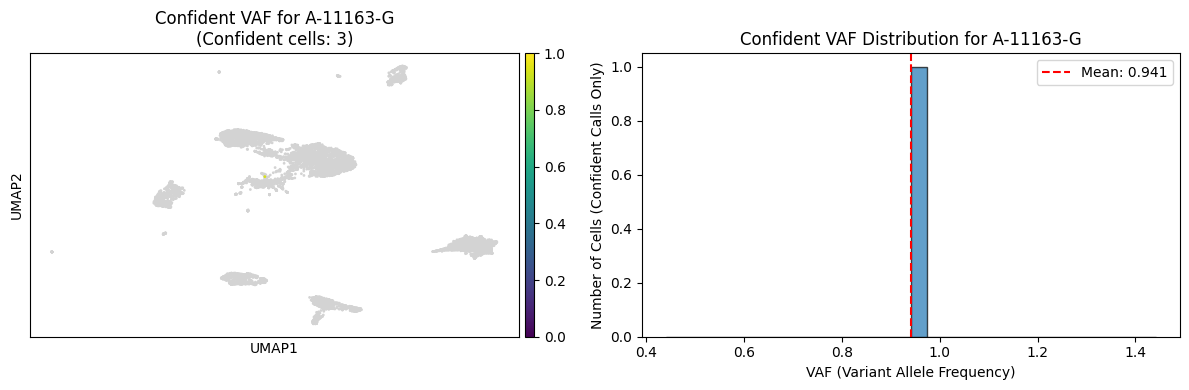

Variant A-11163-G (Index 2):
  Confident cells detected: 3
  Mean coverage: 30.0
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.941
  Confident VAF range: 0.941 - 0.941
---
Processing variant 4: Index 3, Name: A-11225-G
No confident non-zero calls for variant A-11225-G
Processing variant 5: Index 4, Name: A-11382-C


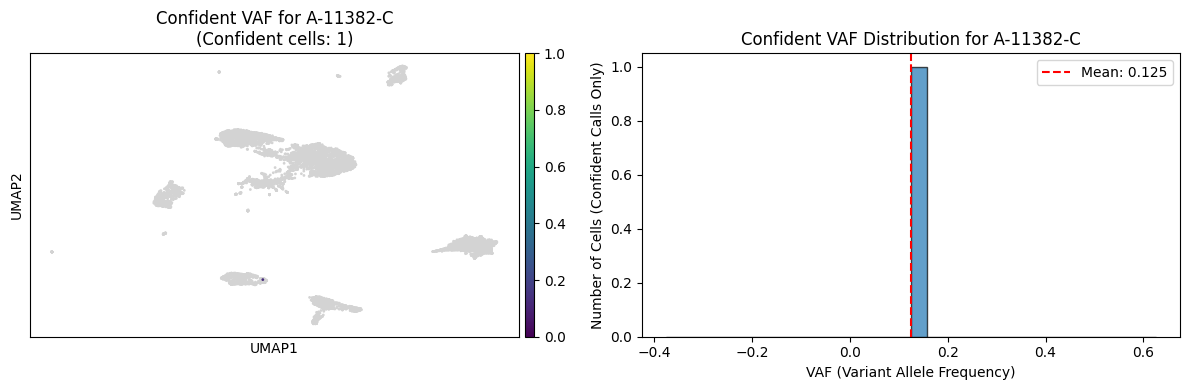

Variant A-11382-C (Index 4):
  Confident cells detected: 1
  Mean coverage: 15.6
  Total cells: 7626
  Confident calls: [False False False ... False False False]
  Confident non-zero calls: 1
  Mean confident VAF: 0.125
  Confident VAF range: 0.125 - 0.125
---


In [ ]:
# Plot confident variants with UMAP and VAF distribution
import matplotlib.pyplot as plt
import numpy as np

# Get confident variants (those with at least one cell having confident detection)
confident_variants = mgatk.uns['variant_summary'][mgatk.uns['variant_summary']['n_cells_conf_detected'] > 0]

print(f"Plotting first 5 confident variants out of {len(confident_variants)} total confident variants")

# Get the variant names list
variant_names = mgatk.uns['variant_names']

for i, variant_idx in enumerate(confident_variants.index[:5]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    
    print(f"Processing variant {i+1}: Index {variant_idx}, Name: {variant_name}")
    
    # Get VAF and confident matrices
    vaf_matrix = mgatk.obsm['variant_vaf']
    confident_matrix = mgatk.obsm['variant_confident']
    
    # Extract VAF and confidence for this specific variant using the integer index
    vaf_values = vaf_matrix[:, variant_idx]
    confident_calls = confident_matrix[:, variant_idx]
    
    # Filter for confident calls AND non-zero VAF
    confident_and_nonzero_mask = confident_calls & (vaf_values > 0)
    
    if not confident_and_nonzero_mask.any():
        print(f"No confident non-zero calls for variant {variant_name}")
        continue
    
    # Get filtered VAF values
    filtered_vaf_values = vaf_values[confident_and_nonzero_mask]
    
    # Create a temporary column for plotting (confident calls only)
    temp_vaf_col = np.zeros(len(mgatk.obs))
    temp_vaf_col[confident_and_nonzero_mask] = filtered_vaf_values
    # Set non-confident or zero calls to NaN for proper plotting
    temp_vaf_col[~confident_and_nonzero_mask] = np.nan
    
    # Add temporary column to obs for plotting
    mgatk.obs[f'temp_vaf_{variant_idx}'] = temp_vaf_col
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # UMAP plot (only confident calls will be colored)
    sc.pl.umap(mgatk, color=f'temp_vaf_{variant_idx}', cmap="viridis", vmin=0, vmax=1, 
               title=f"Confident VAF for {variant_name}\n(Confident cells: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']})", 
               ax=ax1, show=False, na_color='lightgray')
    
    # Histogram of confident VAF values only
    ax2.hist(filtered_vaf_values, bins=30, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('VAF (Variant Allele Frequency)')
    ax2.set_ylabel('Number of Cells (Confident Calls Only)')
    ax2.set_title(f'Confident VAF Distribution for {variant_name}')
    ax2.axvline(filtered_vaf_values.mean(), color='red', linestyle='--', 
                label=f'Mean: {filtered_vaf_values.mean():.3f}')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    total_cells = len(mgatk.obs)
    confident_cells = confident_calls.sum()
    confident_nonzero_cells = len(filtered_vaf_values)
    
    print(f"Variant {variant_name} (Index {variant_idx}):")
    print(f"  Confident cells detected: {confident_variants.loc[variant_idx, 'n_cells_conf_detected']}")
    print(f"  Mean coverage: {confident_variants.loc[variant_idx, 'mean_coverage']:.1f}")
    print(f"  Total cells: {total_cells}")
    print(f"  Confident calls: {confident_calls}")
    print(f"  Confident non-zero calls: {confident_nonzero_cells}")
    print(f"  Mean confident VAF: {filtered_vaf_values.mean():.3f}")
    print(f"  Confident VAF range: {filtered_vaf_values.min():.3f} - {filtered_vaf_values.max():.3f}")
    print("---")
    
    # Clean up temporary column
    mgatk.obs.drop(columns=[f'temp_vaf_{variant_idx}'], inplace=True)

Variant A-10172-G: Insufficient data points (1)
Variant A-10726-G: Insufficient data points (2)
Variant A-11163-G: Insufficient data points (1)
Variant A-11225-G: Insufficient data points (0)
Variant A-11382-C: Insufficient data points (1)
Variant A-11415-C: Insufficient data points (1)


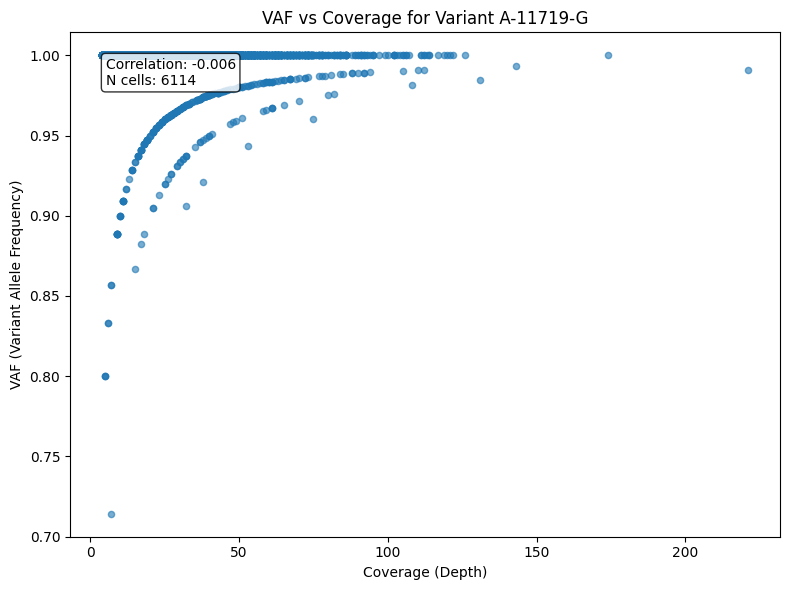

Variant A-11719-G:
  Coverage range: 4.0 - 221.0
  Mean coverage: 25.3
  VAF range: 0.714 - 1.000
  Correlation (VAF vs Coverage): -0.006
---


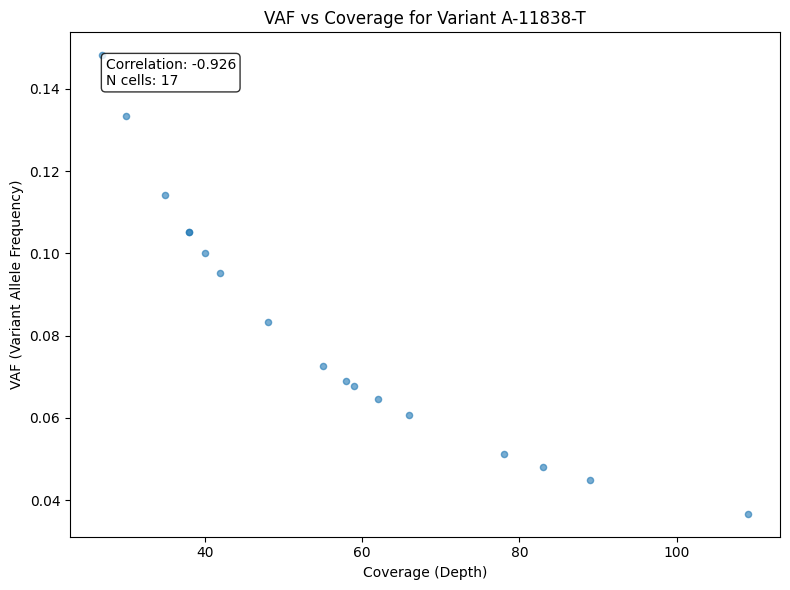

Variant A-11838-T:
  Coverage range: 27.0 - 109.0
  Mean coverage: 56.3
  VAF range: 0.037 - 0.148
  Correlation (VAF vs Coverage): -0.926
---
Variant A-11858-C: Insufficient data points (1)
Variant A-1204-C: Insufficient data points (1)
Variant A-12412-C: Insufficient data points (1)


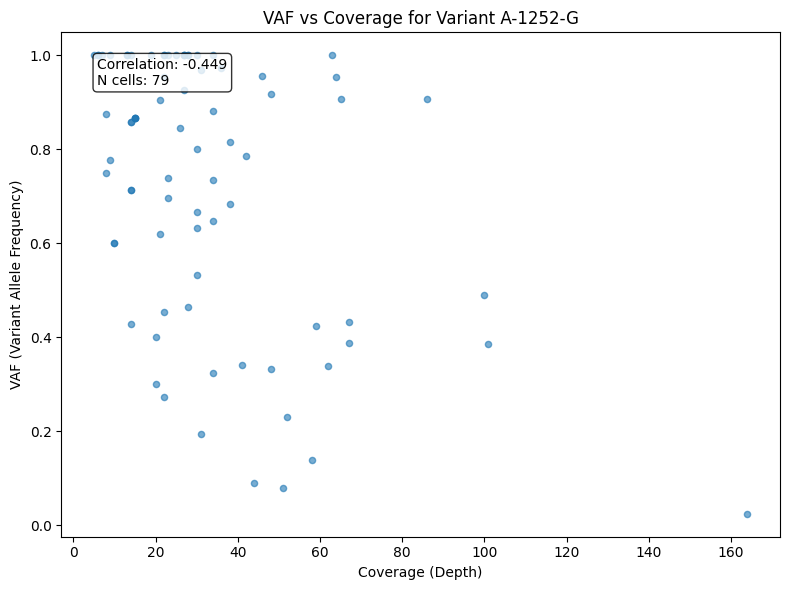

Variant A-1252-G:
  Coverage range: 5.0 - 164.0
  Mean coverage: 32.8
  VAF range: 0.024 - 1.000
  Correlation (VAF vs Coverage): -0.449
---
Variant A-12583-G: Insufficient data points (2)
Variant A-12861-C: Insufficient data points (1)
Variant A-13043-C: Insufficient data points (1)
Variant A-13094-T: Insufficient data points (0)
Variant A-13329-C: Insufficient data points (1)
Variant A-13558-G: Insufficient data points (1)
Variant A-13694-C: Insufficient data points (1)
Variant A-13730-G: Insufficient data points (1)
Variant A-13879-T: Insufficient data points (1)
Variant A-14721-G: Insufficient data points (1)
Variant A-1476-G: Insufficient data points (2)
Variant A-14991-T: Insufficient data points (0)
Variant A-15093-G: Insufficient data points (3)
Variant A-15170-G: Insufficient data points (0)
Variant A-15301-G: Insufficient data points (3)
Variant A-15708-G: Insufficient data points (4)


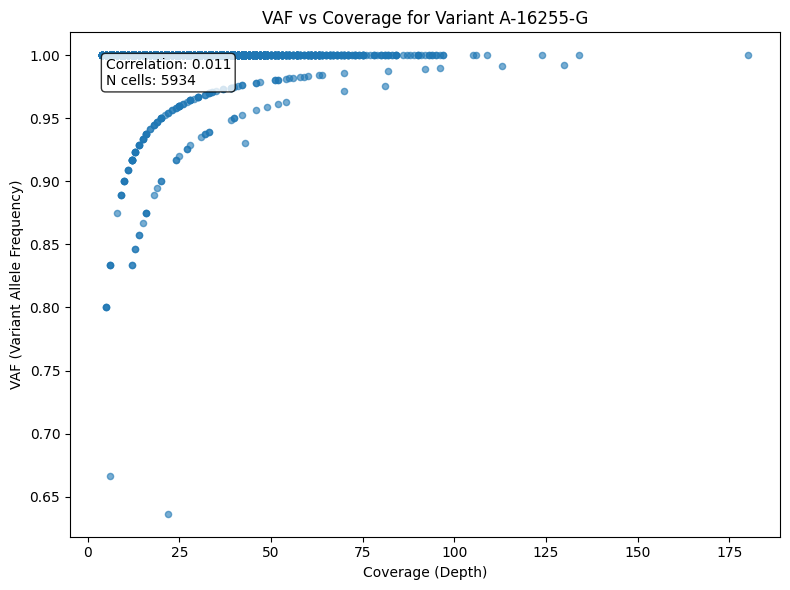

Variant A-16255-G:
  Coverage range: 4.0 - 180.0
  Mean coverage: 20.7
  VAF range: 0.636 - 1.000
  Correlation (VAF vs Coverage): 0.011
---


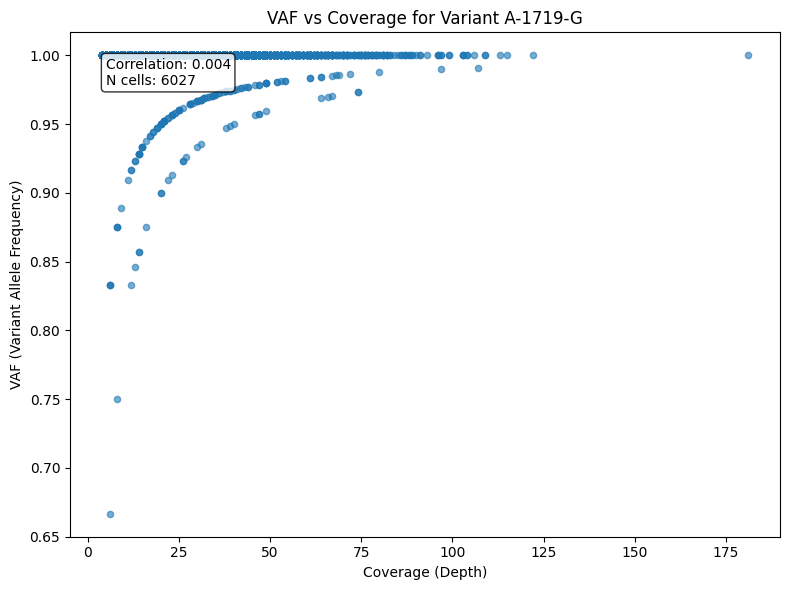

Variant A-1719-G:
  Coverage range: 4.0 - 181.0
  Mean coverage: 23.1
  VAF range: 0.667 - 1.000
  Correlation (VAF vs Coverage): 0.004
---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the matrices and variant info
vaf_matrix = mgatk.obsm['variant_vaf']        # cells x variants
coverage_matrix = mgatk.obsm['variant_coverage']  # cells x variants  
variant_names = mgatk.uns['variant_names']

# For variants in your confident_variants
for i, variant_idx in enumerate(confident_variants.index[:30]):  # Plot top 5 confident variants
    # variant_idx is already the integer index we need
    variant_name = variant_names[variant_idx]  # Get the actual variant name string
    try:
        variant_idx = confident_variants.index[i]  # Get the actual variant index
        # Find the index of this variant in the variant_names list
        variant_idx = variant_names.index(variant_name)
        
        # Get VAF and coverage values for this variant across all cells
        vaf_values = vaf_matrix[:, variant_idx]
        coverage_values = coverage_matrix[:, variant_idx]
        
        # Filter for cells with non-zero VAF and valid coverage
        mask = (vaf_values > 0) & (coverage_values > 0)
        
        if mask.sum() > 5:  # Need at least 5 points for meaningful plot
            filtered_vaf = vaf_values[mask]
            filtered_coverage = coverage_values[mask]
            
            # Create scatter plot
            fig, ax = plt.subplots(1, 1, figsize=(8, 6))
            
            scatter = ax.scatter(filtered_coverage, filtered_vaf, alpha=0.6, s=20)
            ax.set_xlabel('Coverage (Depth)')
            ax.set_ylabel('VAF (Variant Allele Frequency)')
            ax.set_title(f'VAF vs Coverage for Variant {variant_name}')
            
            # Add statistics
            if len(filtered_coverage) > 1 and len(set(filtered_coverage)) > 1:
                correlation = np.corrcoef(filtered_coverage, filtered_vaf)[0, 1]
            else:
                correlation = np.nan
                
            ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}\nN cells: {len(filtered_vaf)}', 
                    transform=ax.transAxes, verticalalignment='top', 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            plt.tight_layout()
            plt.show()
            
            # Print summary
            print(f"Variant {variant_name}:")
            print(f"  Coverage range: {filtered_coverage.min():.1f} - {filtered_coverage.max():.1f}")
            print(f"  Mean coverage: {filtered_coverage.mean():.1f}")
            print(f"  VAF range: {filtered_vaf.min():.3f} - {filtered_vaf.max():.3f}")
            print(f"  Correlation (VAF vs Coverage): {correlation:.3f}")
            print("---")
        else:
            print(f"Variant {variant_name}: Insufficient data points ({mask.sum()})")
            
    except Exception as e:
        print(f"Error processing variant {variant_name}: {e}")

In [ ]:
import numpy as np
import pandas as pd

# Get the matrices
vaf_matrix = mgatk.obsm['variant_vaf'].copy()  # Make a copy to modify
coverage_matrix = mgatk.obsm['variant_coverage']
confident_matrix = mgatk.obsm['variant_confident']
variant_names = mgatk.uns['variant_names']
variant_summary = mgatk.uns['variant_summary']

print(f"Original VAF matrix shape: {vaf_matrix.shape}")
print(f"Non-zero VAF values before filtering: {(vaf_matrix > 0).sum()}")

# Count variants with at least one expressing cell before filtering
variants_with_expression_before = (vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell before filtering: {variants_with_expression_before}")

# Create high-quality filtered VAF matrix
high_quality_vaf_matrix = vaf_matrix.copy()
variant_names_list = []
# For each variant, apply cell-level quality filters
for i, variant_name in enumerate(variant_names):
    # Get variant-level statistics
    variant_stats = variant_summary.iloc[i]
    strand_concordance = variant_stats['strand_concordance']
    variance = variant_stats['variance'] 
    mean_coverage = variant_stats['mean_coverage']
    
    # Get cell-level data for this variant
    cell_vaf = vaf_matrix[:, i]
    cell_coverage = coverage_matrix[:, i]
    cell_confident = confident_matrix[:, i]
    
    # Define quality criteria for this variant's cells
    quality_mask = (
        (strand_concordance >= 0.5) &  # Variant-level criterion
        (mean_coverage >= 20) &        # Variant-level criterion
        (cell_vaf >= 0.1)        # Cell-level: VAF > 10%
    )
    
    # Set non-qualifying cells to 0 for this variant
    high_quality_vaf_matrix[~quality_mask, i] = 0

print(f"Non-zero VAF values after high-quality filtering: {(high_quality_vaf_matrix > 0).sum()}")
print(f"Percentage of calls retained: {(high_quality_vaf_matrix > 0).sum() / (vaf_matrix > 0).sum() * 100:.1f}%")

# Count variants with at least one expressing cell after filtering
variants_with_expression_after = (high_quality_vaf_matrix > 0).any(axis=0).sum()
print(f"Variants with at least one expressing cell after filtering: {variants_with_expression_after}")
print(f"Percentage of variants retained: {variants_with_expression_after / variants_with_expression_before * 100:.1f}%")

# Count variants completely eliminated by filtering
variants_eliminated = variants_with_expression_before - variants_with_expression_after
print(f"Variants completely eliminated by filtering: {variants_eliminated}")
print("variants left" , variants_with_expression_after)
# Store the high-quality filtered matrix
mgatk.obsm['variant_vaf_high_quality'] = high_quality_vaf_matrix

# Now you can use this filtered matrix for analysis
print("\nHigh-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']")

Original VAF matrix shape: (7626, 4710)
Non-zero VAF values before filtering: 169464
Variants with at least one expressing cell before filtering: 4113
Non-zero VAF values after high-quality filtering: 71866
Percentage of calls retained: 42.4%
Variants with at least one expressing cell after filtering: 2363
Percentage of variants retained: 57.5%
Variants completely eliminated by filtering: 1750
variants left 2363

High-quality filtered VAF matrix stored in mgatk.obsm['variant_vaf_high_quality']


In [ ]:
# Boolean mask: True for variants with at least one retained (non-zero) cell
high_quality_mask = (high_quality_vaf_matrix > 0).any(axis=0)

# Get corresponding variant names
high_quality_variant_names = np.array(variant_names)[high_quality_mask]
print(high_quality_variant_names)
print(len(high_quality_variant_names))

## Flip variants to match format 
converted = [f"MT-{alt}-{pos}-{ref}" for ref, pos, alt in (v.split('-') for v in high_quality_variant_names)]
print(converted)

required_columns = ["chr", "pos", "ref", "alt"]

genebe_df = pd.DataFrame(
    [v.split('-') for v in converted],
    columns=["chr","ref", "pos", "alt"]
)
genebe_df = genebe_df[required_columns]

print(genebe_df.head())

['A-10172-G' 'A-11163-G' 'A-11719-G' ... 'G-8784-A' 'G-8860-A' 'G-982-A']
2363
['MT-G-10172-A', 'MT-G-11163-A', 'MT-G-11719-A', 'MT-T-11838-A', 'MT-C-12412-A', 'MT-G-1252-A', 'MT-G-12583-A', 'MT-C-12861-A', 'MT-G-13558-A', 'MT-G-13730-A', 'MT-G-1476-A', 'MT-G-15093-A', 'MT-G-15301-A', 'MT-G-15708-A', 'MT-G-1719-A', 'MT-G-1949-A', 'MT-G-2174-A', 'MT-G-2553-A', 'MT-G-3688-A', 'MT-G-3850-A', 'MT-c-4393-A', 'MT-G-4482-A', 'MT-G-4830-A', 'MT-G-4849-A', 'MT-G-5245-A', 'MT-G-529-A', 'MT-G-5590-A', 'MT-G-6069-A', 'MT-G-6999-A', 'MT-G-7239-A', 'MT-G-769-A', 'MT-G-8007-A', 'MT-G-8189-A', 'MT-G-874-A', 'MT-G-9267-A', 'MT-G-9554-A', 'MT-G-9906-A', 'MT-G-10172-C', 'MT-T-11147-C', 'MT-T-11759-C', 'MT-T-11784-C', 'MT-T-12448-C', 'MT-T-12755-C', 'MT-T-12851-C', 'MT-T-13698-C', 'MT-T-13781-C', 'MT-T-13946-C', 'MT-T-1413-C', 'MT-T-14345-C', 'MT-T-14395-C', 'MT-T-14819-C', 'MT-T-14826-C', 'MT-T-14912-C', 'MT-T-14956-C', 'MT-G-15301-C', 'MT-T-15394-C', 'MT-T-15519-C', 'MT-T-15755-C', 'MT-T-15774-C', 'MT-T

In [ ]:
import genebe as gnb
annotated_PBMC = gnb.annotate_dataframe_variants(genebe_df,use_ensembl=True,use_refseq=False, genome='hg38', flatten_consequences=False)

2025-10-21 16:06:46 - WARNING - You are not logged in to GeneBe. We recommend using username and api_key arguments. Find out more on https://genebe.net/api .


Error: .netrc file not found.


100%|██████████| 24/24 [00:11<00:00,  2.17it/s]


In [ ]:
annotated_PBMC.to_csv('PBMC_PostMortem_genebe.csv', index=False)

In [ ]:
#Gene classification 
gene_classification = {
    'MT-ND1': 'Complex I',
    'MT-ND2': 'Complex I',
    'MT-ND3': 'Complex I',
    'MT-ND4': 'Complex I',
    'MT-ND4L': 'Complex I',
    'MT-ND5': 'Complex I',
    'MT-ND6': 'Complex I',
    'MT-CO1': 'Complex IV',
    'MT-CO2': 'Complex IV',
    'MT-CO3': 'Complex IV',
    'MT-CYB': 'Complex III',
    'MT-ATP6': 'Complex V',
    'MT-ATP8': 'Complex V',
    'MT-RNR1': 'rRNA',
    'MT-RNR2': 'rRNA',
    'MT-TF': 'tRNA',  
    'MT-TV': 'tRNA',
    'MT-TI': 'tRNA',
    'MT-TL1': 'tRNA',
    'MT-TL2': 'tRNA',
    'MT-TK': 'tRNA',
    'MT-TM': 'tRNA',
    'MT-TP': 'tRNA',
    'MT-TS1': 'tRNA',
    'MT-TS2': 'tRNA',
    'MT-TW': 'tRNA',
    'MT-TA': 'tRNA',
    'MT-TC': 'tRNA',
    'MT-TY': 'tRNA',
    'MT-TH': 'tRNA',
    'MT-TG': 'tRNA',
    'MT-TR': 'tRNA',
    'MT-TN': 'tRNA',
    'MT-TD': 'tRNA',
    'MT-TE': 'tRNA',
    'MT-TQ': 'tRNA'
}

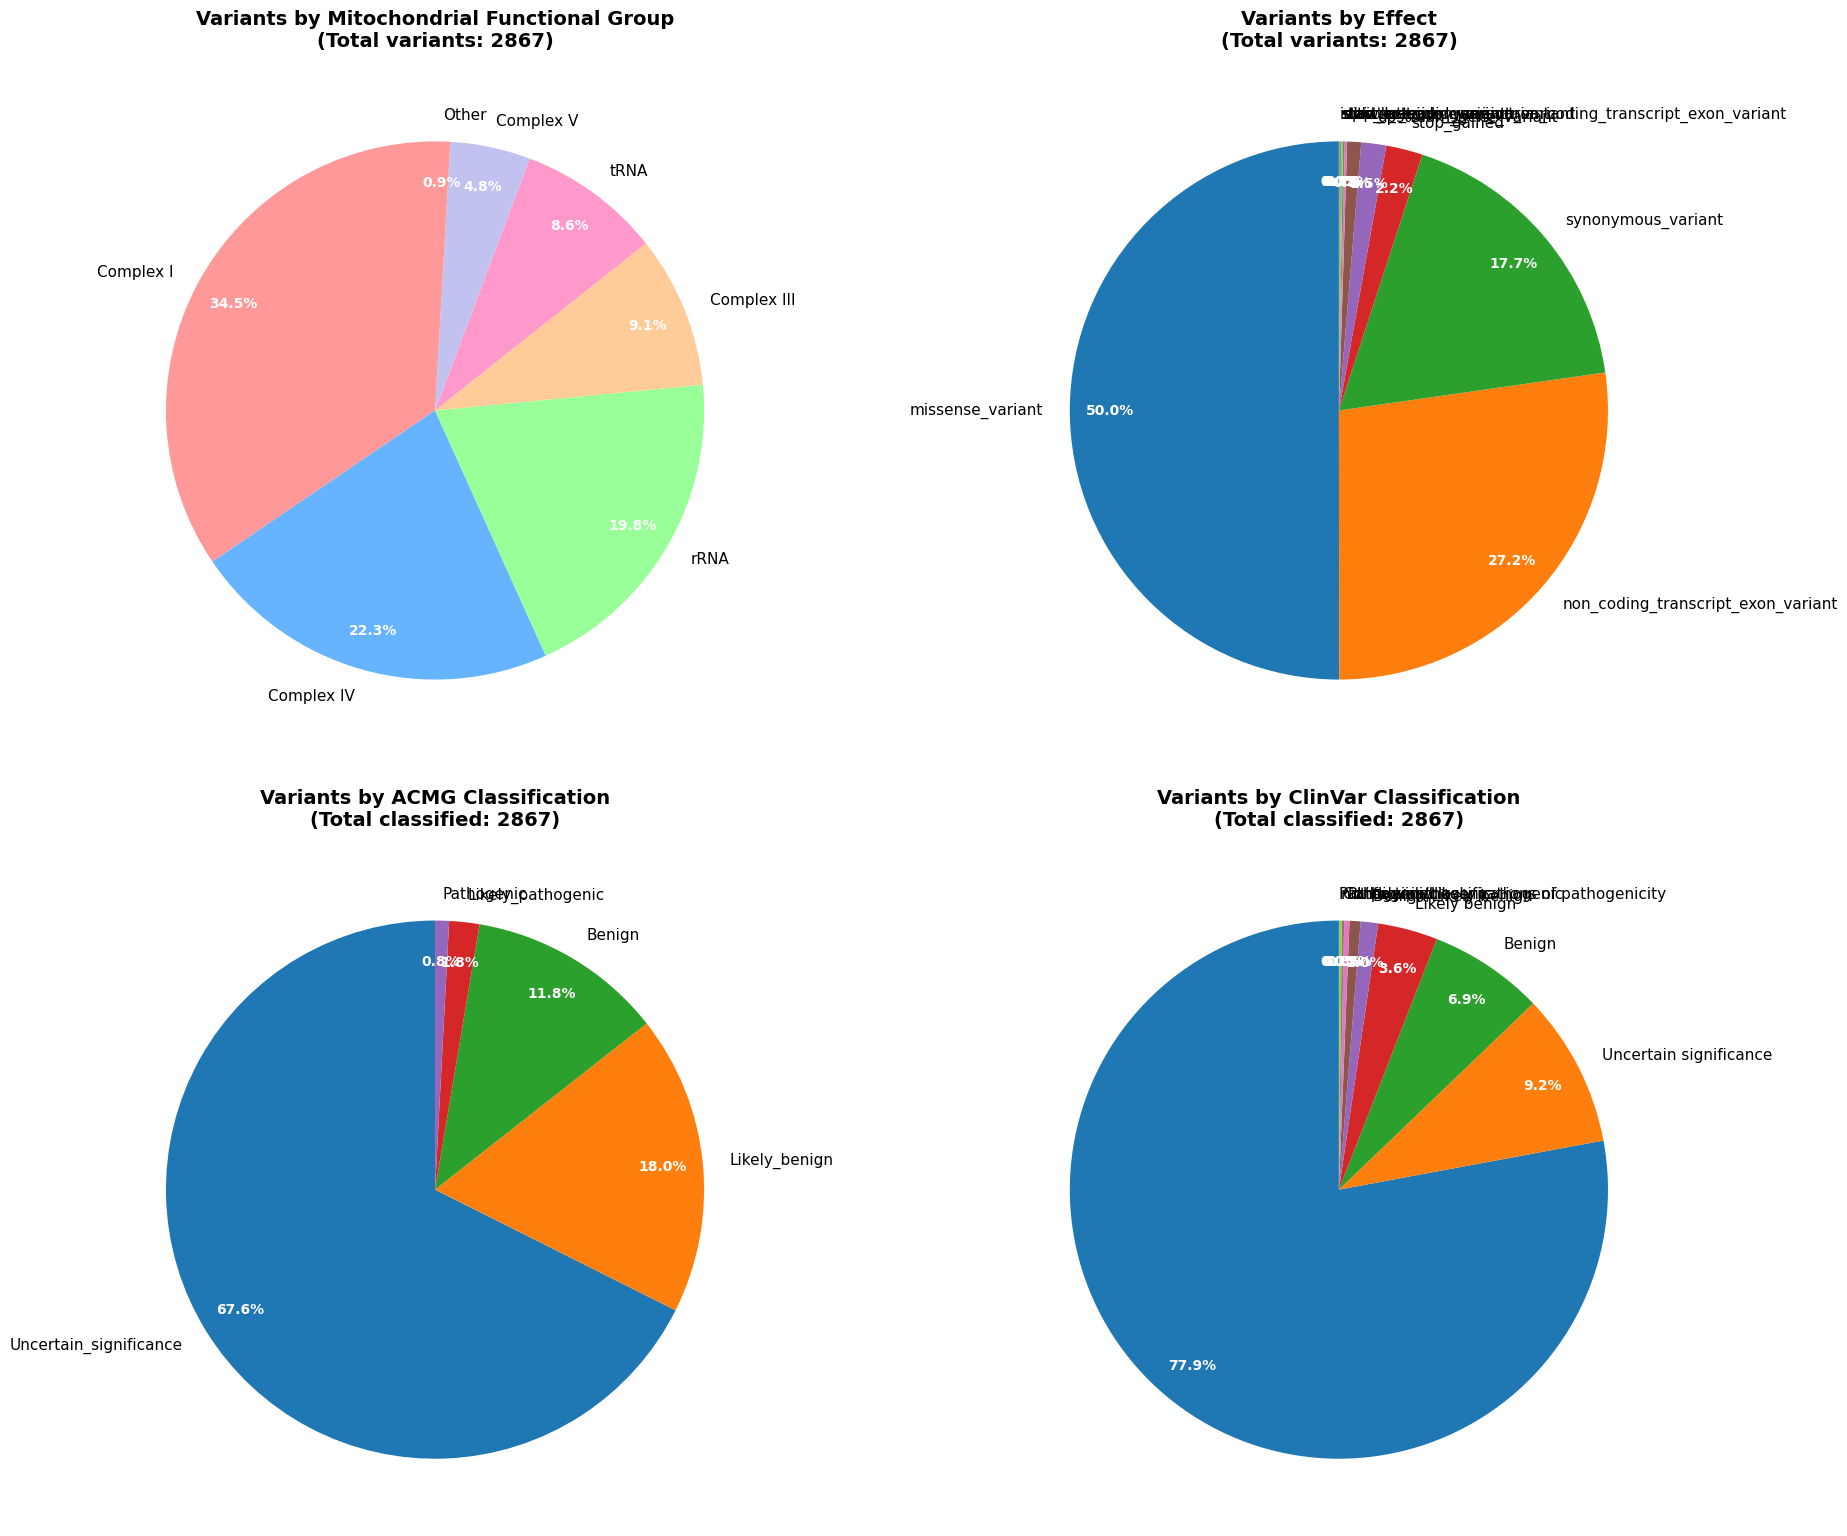

=== SUMMARY STATISTICS ===

1. Mitochondrial Functional Group Distribution:
   Total functional groups represented: 7
   Most common functional group: Complex I (989 variants)
   All functional groups:
      Complex I: 989 variants (34.5%)
      Complex IV: 638 variants (22.3%)
      rRNA: 567 variants (19.8%)
      Complex III: 262 variants (9.1%)
      tRNA: 247 variants (8.6%)
      Complex V: 138 variants (4.8%)
      Other: 26 variants (0.9%)

2. Individual Gene Symbol Distribution:
   Total genes represented: 32
   Most common gene: MT-ND5 (339 variants)
   Top 10 genes:
      1. MT-ND5 (Complex I): 339 variants (11.8%)
      2. MT-CO1 (Complex IV): 327 variants (11.4%)
      3. MT-RNR2 (rRNA): 314 variants (11.0%)
      4. MT-CYB (Complex III): 262 variants (9.1%)
      5. MT-RNR1 (rRNA): 253 variants (8.8%)
      6. MT-ND4 (Complex I): 209 variants (7.3%)
      7. MT-ND1 (Complex I): 183 variants (6.4%)
      8. MT-CO3 (Complex IV): 162 variants (5.7%)
      9. MT-CO2 (Complex 

In [ ]:
# Create a copy of the dataframe and add the functional classification
annotated_PBMC_classified = annotated_PBMC.copy()
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_symbol'].map(gene_classification)

# Handle any genes not in the classification (mark as 'Other')
annotated_PBMC_classified['gene_functional_group'] = annotated_PBMC_classified['gene_functional_group'].fillna('Other')

# Create a 2x2 subplot layout for the pie charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))  # Increased figure size

# Function to prepare data for pie chart (handle NaN values and limit categories)
def prepare_pie_data(series, max_categories=20):
    # Count values, excluding NaN
    value_counts = series.value_counts(dropna=True)
    
    # If there are more categories than max_categories, group the smallest ones as "Other"
    if len(value_counts) > max_categories:
        top_categories = value_counts.head(max_categories - 1)
        other_count = value_counts.iloc[max_categories - 1:].sum()
        
        # Create new series with "Other" category
        pie_data = top_categories.copy()
        pie_data['Other'] = other_count
    else:
        pie_data = value_counts
    
    return pie_data

# 1. Gene Functional Group pie chart (using your classification)
gene_functional_data = prepare_pie_data(annotated_PBMC_classified['gene_functional_group'])
colors1 = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc', '#c2c2f0']  # Custom colors for complexes

# Option 1: Use pctdistance and labeldistance to control spacing
wedges1, texts1, autotexts1 = ax1.pie(gene_functional_data.values, labels=gene_functional_data.index, 
                                       autopct='%1.1f%%', startangle=90, 
                                       colors=colors1[:len(gene_functional_data)],
                                       pctdistance=0.85,    # Distance of percentage labels from center
                                       labeldistance=1.1)   # Distance of category labels from center

# Adjust text properties to prevent overlap
for autotext in autotexts1:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts1:
    text.set_fontsize(11)

ax1.set_title(f'Variants by Mitochondrial Functional Group\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 2. Effect pie chart with adjusted spacing
effect_data = prepare_pie_data(annotated_PBMC['effect'])
wedges2, texts2, autotexts2 = ax2.pie(effect_data.values, labels=effect_data.index, 
                                       autopct='%1.1f%%', startangle=90,
                                       pctdistance=0.85, labeldistance=1.1)

for autotext in autotexts2:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts2:
    text.set_fontsize(11)

ax2.set_title(f'Variants by Effect\n(Total variants: {len(annotated_PBMC)})', 
              fontsize=14, fontweight='bold', pad=20)

# 3. ACMG Classification pie chart
acmg_data = prepare_pie_data(annotated_PBMC['acmg_classification'])
if len(acmg_data) > 0:
    wedges3, texts3, autotexts3 = ax3.pie(acmg_data.values, labels=acmg_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts3:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts3:
        text.set_fontsize(11)
    
    ax3.set_title(f'Variants by ACMG Classification\n(Total classified: {acmg_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax3.text(0.5, 0.5, 'No ACMG Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax3.set_title('ACMG Classification', fontsize=14, fontweight='bold', pad=20)

# 4. ClinVar Classification pie chart
clinvar_data = prepare_pie_data(annotated_PBMC['clinvar_classification'])
if len(clinvar_data) > 0:
    wedges4, texts4, autotexts4 = ax4.pie(clinvar_data.values, labels=clinvar_data.index, 
                                           autopct='%1.1f%%', startangle=90,
                                           pctdistance=0.85, labeldistance=1.1)
    
    for autotext in autotexts4:
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')
        autotext.set_color('white')
    
    for text in texts4:
        text.set_fontsize(11)
    
    ax4.set_title(f'Variants by ClinVar Classification\n(Total classified: {clinvar_data.sum()})', 
                  fontsize=14, fontweight='bold', pad=20)
else:
    ax4.text(0.5, 0.5, 'No ClinVar Classifications\nAvailable', ha='center', va='center', fontsize=12)
    ax4.set_title('ClinVar Classification', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout(pad=3.0)  # Add more padding between subplots
plt.show()

# Print summary statistics for each category
print("=== SUMMARY STATISTICS ===")
print(f"\n1. Mitochondrial Functional Group Distribution:")
functional_summary = annotated_PBMC_classified['gene_functional_group'].value_counts(dropna=True)
print(f"   Total functional groups represented: {len(functional_summary)}")
print(f"   Most common functional group: {functional_summary.index[0]} ({functional_summary.iloc[0]} variants)")
print(f"   All functional groups:")
for group, count in functional_summary.items():
    print(f"      {group}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n2. Individual Gene Symbol Distribution:")
gene_summary = annotated_PBMC['gene_symbol'].value_counts(dropna=True)
print(f"   Total genes represented: {len(gene_summary)}")
print(f"   Most common gene: {gene_summary.index[0]} ({gene_summary.iloc[0]} variants)")
print(f"   Top 10 genes:")
for i, (gene, count) in enumerate(gene_summary.head(10).items()):
    functional_group = gene_classification.get(gene, 'Other')
    print(f"      {i+1}. {gene} ({functional_group}): {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

print(f"\n3. Effect Distribution:")
effect_summary = annotated_PBMC['effect'].value_counts(dropna=True)
print(f"   Total effect types: {len(effect_summary)}")
if len(effect_summary) > 0:
    print(f"   Most common effect: {effect_summary.index[0]} ({effect_summary.iloc[0]} variants)")
    print(f"   All effects:")
    for effect, count in effect_summary.items():
        print(f"      {effect}: {count} variants ({count/len(annotated_PBMC)*100:.1f}%)")

acmg_summary = annotated_PBMC['acmg_classification'].value_counts(dropna=True)
print(f"\n4. ACMG Classification Distribution:")
print(f"   Total ACMG classified variants: {annotated_PBMC['acmg_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['acmg_classification'].isna().sum()}")
for classification, count in acmg_summary.items():
    print(f"      {classification}: {count} variants")

print(f"\n5. ClinVar Classification Distribution:")
clinvar_summary = annotated_PBMC['clinvar_classification'].value_counts(dropna=True)
print(f"   Total ClinVar classified variants: {annotated_PBMC['clinvar_classification'].notna().sum()}")
print(f"   Unclassified variants: {annotated_PBMC['clinvar_classification'].isna().sum()}")
if len(clinvar_summary) > 0:
    for classification, count in clinvar_summary.items():
        print(f"      {classification}: {count} variants")

In [ ]:
## Import mitoTIP dataframe to look at tRNA variants only 
mitoTIP = pd.read_csv('/Users/lucascortes/Library/CloudStorage/OneDrive-Personal/Documents/Work/Pickett/ATAC-Seq/Usefull_Stuff/mitotip_scores.txt', sep='\t')
mitoTIP.head(20)

,Position,rCRS,Alt,MitoTIP_Score,Quartile,Count,Percentage,Mitomap_Status
0,577,G,:,20.3833,Q1,0,0.0,Absent
1,577,G,A,17.7500,Q1,0,0.0,Absent
2,577,G,C,17.7500,Q1,0,0.0,Absent
3,577,G,T,17.7500,Q1,0,0.0,Absent
4,578,T,:,18.6851,Q1,0,0.0,Absent
5,578,T,A,18.6851,Q1,0,0.0,Absent
6,578,T,C,16.6004,Q1,0,0.0,Absent
7,578,T,G,18.6851,Q1,0,0.0,Absent
8,579,T,:,17.6526,Q1,0,0.0,Absent
9,579,T,A,17.6526,Q1,0,0.0,Absent


In [ ]:
## Dataframe containing tRNA variants likely or poissbly pathogenic as per mitoTIP scoring method 
mitoTIP_filtered = mitoTIP[(mitoTIP['Quartile'] == 'Q2') | (mitoTIP['Quartile'] == 'Q1')]
mitoTIP_filtered.head(20)

Empty DataFrame
Columns: [Position, rCRS, Alt, MitoTIP_Score, Quartile, Count, Percentage, Mitomap_Status]
Index: []
